In [ ]:
%load_ext autoreload
%autoreload 2

In [5]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path
import os

import numpy as np
import seaborn as sns
import os
from analysis.utils import load_sweep_metadata, load_data, compute_success, chunk_data
from analysis.utils_decoding import evaluate_lags_leave_k_out

## Load results 

In [12]:
path = "/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_sac_vs_tdmpc2/passive_data"


def load_decoding_results(path, predict_type, model):
    """Load decoding results from pickle file."""
    with open(
            os.path.join(
                path,
                f'results_decoding_{predict_type}_{model}_passive_data.pkl'),
            'rb') as f:
        return pickle.load(f)


# Load all combinations
results_decoding = {}
for model in ['linear_regression', 'lasso']:
    for predict_type in ['future', 'difference']:
        key = f'{predict_type}_{model}'
        results_decoding[key] = load_decoding_results(path, predict_type, model)

FileNotFoundError: [Errno 2] No such file or directory: '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_sac_vs_tdmpc2/passive_data/results_decoding_difference_lasso_passive_data.pkl'

In [11]:
results['future_linear_regression']

KeyError: 'future_linear_regression'

## Decoding

In [9]:
decoding_relationships = [
    #('z', 'obs'),
    #('obs', 'obs'),
    ('position', 'position'),
    ('cos(pole_angle)', 'cos(pole_angle)'),
    ('sin(pole_angle)', 'sin(pole_angle)'),
    ('cart_velocity', 'cart_velocity'),
    ('pole_angular_velocity', 'pole_angular_velocity'),
    ('rewards', 'rewards'),
    ('actions', 'actions'),
    ('z_tdmpc2', 'position'),
    ('z_tdmpc2', 'cos(pole_angle)'),
    ('z_tdmpc2', 'sin(pole_angle)'),
    ('z_tdmpc2', 'cart_velocity'),
    ('z_tdmpc2', 'pole_angular_velocity'),
    ('z_tdmpc2', 'rewards'),
    ('z_tdmpc2', 'actions'),
    ('z_sac', 'position'),
    ('z_sac', 'cos(pole_angle)'),
    ('z_sac', 'sin(pole_angle)'),
    ('z_sac', 'cart_velocity'),
    ('z_sac', 'pole_angular_velocity'),
    ('z_sac', 'rewards'),
    ('z_sac', 'actions'),
]


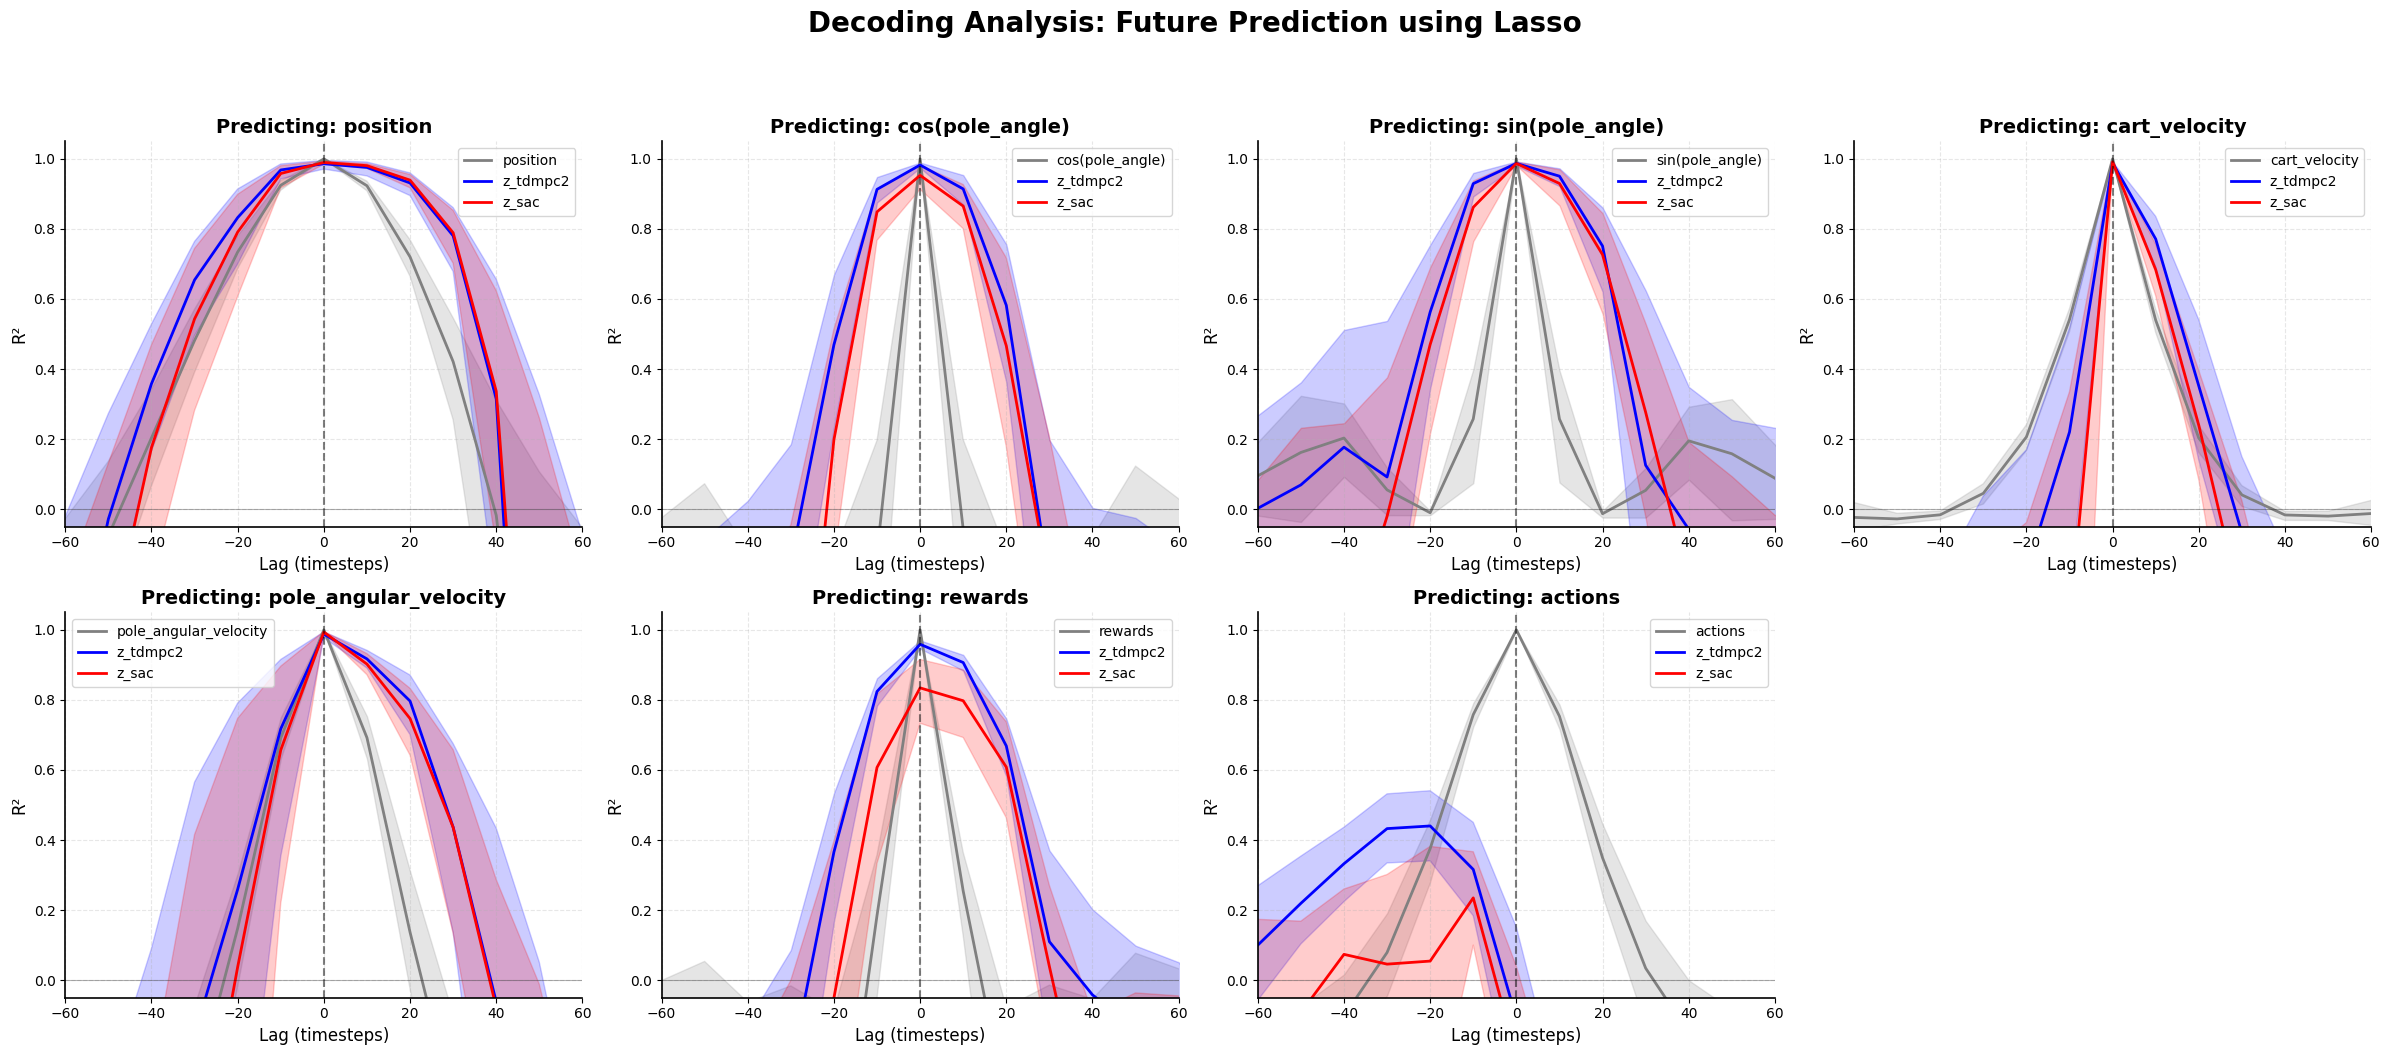

In [52]:
# Group plot keys by y variable
y_variables = [
    'position', 'cos(pole_angle)', 'sin(pole_angle)', 'cart_velocity',
    'pole_angular_velocity', 'rewards', 'actions'
]

# Create figure with 2 rows and enough columns for all y variables
n_vars = len(y_variables)
n_cols = (n_vars + 1) // 2  # Ceiling division to get number of columns needed
fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 6, 10))
axes = axes.flatten()  # Flatten to make indexing easier

regression_type = 'future'
model = 'lasso'

# Define colors for each x variable type
color_map = {
    'z_sac': 'red',
    'z_tdmpc2': 'blue',
    'position': 'gray',
    'cos(pole_angle)': 'gray',
    'sin(pole_angle)': 'gray',
    'cart_velocity': 'gray',
    'pole_angular_velocity': 'gray',
    'rewards': 'gray',
    'actions': 'gray'
}

for idx, y_var in enumerate(y_variables):
    # Get all x variables that predict this y variable
    plot_keys = [(x_var, y_var)
                 for x_var, y_var_check in decoding_relationships
                 if y_var_check == y_var]

    if not plot_keys:
        continue

    ax = axes[idx]

    # Plot each x variable as a separate line
    for x_var, _ in plot_keys:
        key = f'{x_var}-{y_var}'

        if key in results_decoding[f'{regression_type}_{model}']:
            results = results_decoding[f'{regression_type}_{model}'][key]

            r2_mean = results['r2_mean']
            r2_ci = results['r2_ci']
            lags = list(r2_mean.keys())
            means = list(r2_mean.values())
            ci_lower = [r2_ci[lag][0] for lag in lags]
            ci_upper = [r2_ci[lag][1] for lag in lags]

            color = color_map.get(x_var, 'black')
            ax.plot(lags, means, linewidth=2, label=x_var, color=color)
            ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2, color=color)

    ax.set_xlabel('Lag (timesteps)', fontsize=12)
    ax.set_ylabel('R²', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-60, 60)
    ax.tick_params(labelsize=10)
    ax.set_title(f'Predicting: {y_var}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# Hide any unused subplots
for idx in range(len(y_variables), len(axes)):
    axes[idx].set_visible(False)

# Add overall title
fig.suptitle(
    f'Decoding Analysis: {regression_type.capitalize()} Prediction using {model.replace("_", " ").title()}',
    fontsize=20,
    fontweight='bold',
    y=1.05)

plt.tight_layout()
sns.despine()
plt.show()

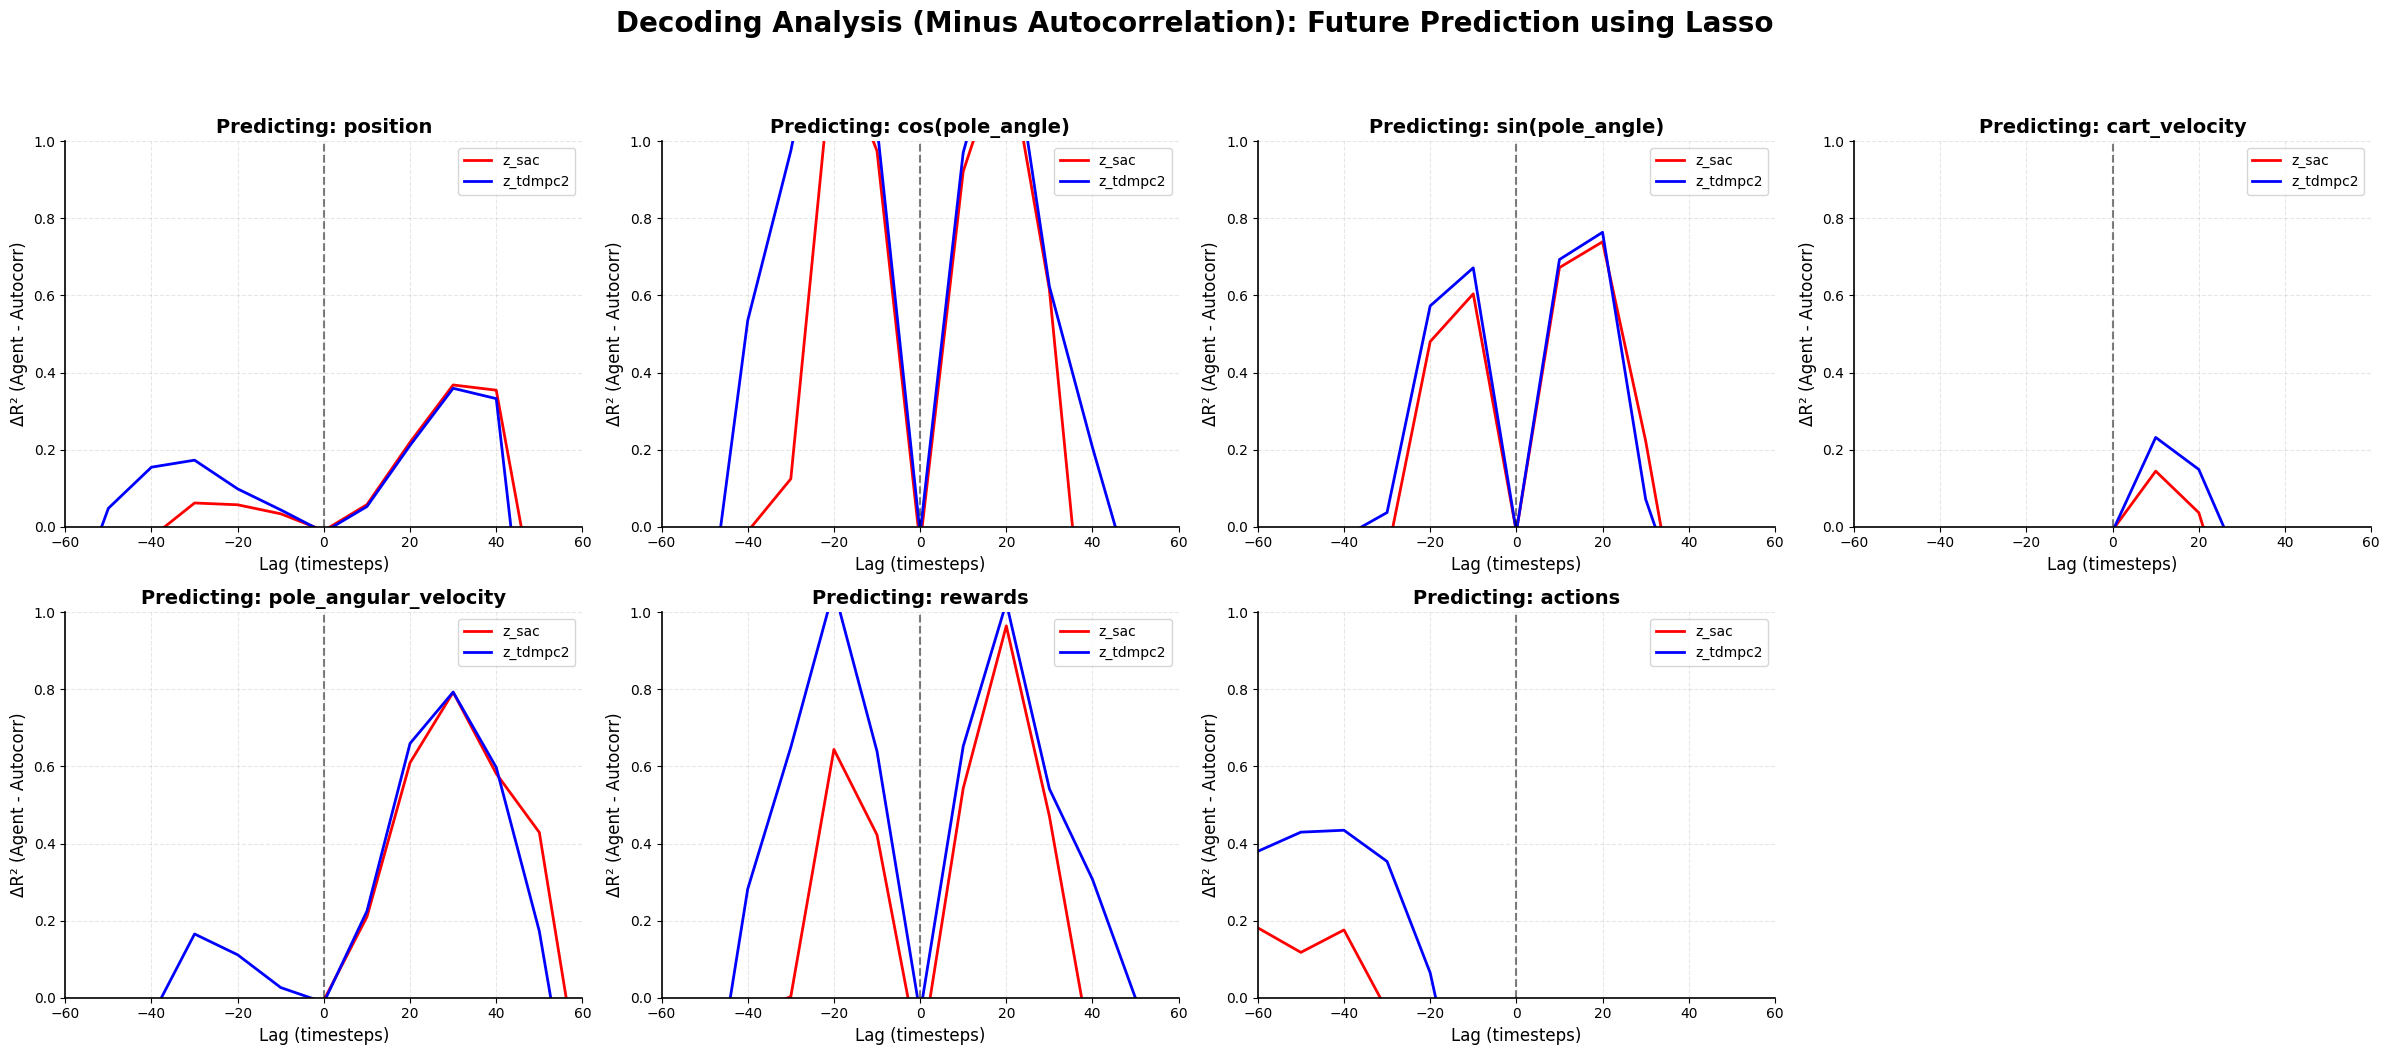

In [41]:
# Group plot keys by y variable
y_variables = [
    'position', 'cos(pole_angle)', 'sin(pole_angle)', 'cart_velocity',
    'pole_angular_velocity', 'rewards', 'actions'
]

# Create figure with 2 rows and enough columns for all y variables
n_vars = len(y_variables)
n_cols = (n_vars + 1) // 2  # Ceiling division to get number of columns needed
fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 6, 10))
axes = axes.flatten()  # Flatten to make indexing easier

regression_type = 'future'
model = 'lasso'

# Define colors for each agent
color_map = {'z_sac': 'red', 'z_tdmpc2': 'blue'}

for idx, y_var in enumerate(y_variables):
    ax = axes[idx]

    # Plot the difference (agent prediction - autocorrelation) for each agent
    for agent in ['z_sac', 'z_tdmpc2']:
        # Get agent prediction results
        agent_key = f'{agent}-{y_var}'
        # Get autocorrelation results
        autocorr_key = f'{y_var}-{y_var}'

        if agent_key in results_decoding[f'{regression_type}_{model}'] and \
           autocorr_key in results_decoding[f'{regression_type}_{model}']:

            agent_results = results_decoding[f'{regression_type}_{model}'][
                agent_key]
            autocorr_results = results_decoding[f'{regression_type}_{model}'][
                autocorr_key]

            agent_r2_mean = agent_results['r2_mean']
            autocorr_r2_mean = autocorr_results['r2_mean']

            # Calculate difference
            lags = list(agent_r2_mean.keys())
            diff_means = [
                agent_r2_mean[lag] - autocorr_r2_mean.get(lag, 0)
                for lag in lags
            ]

            # Calculate CI for difference (approximate)
            agent_r2_ci = agent_results['r2_ci']
            autocorr_r2_ci = autocorr_results['r2_ci']
            ci_lower = [
                agent_r2_ci[lag][0] - autocorr_r2_ci.get(lag, (0, 0))[1]
                for lag in lags
            ]
            ci_upper = [
                agent_r2_ci[lag][1] - autocorr_r2_ci.get(lag, (0, 0))[0]
                for lag in lags
            ]

            color = color_map.get(agent, 'black')
            ax.plot(lags, diff_means, linewidth=2, label=agent, color=color)
            #ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2, color=color)

    ax.set_xlabel('Lag (timesteps)', fontsize=12)
    ax.set_ylabel('ΔR² (Agent - Autocorr)', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
    ax.set_ylim(-0, 1.0)
    ax.set_xlim(-60, 60)
    ax.tick_params(labelsize=10)
    ax.set_title(f'Predicting: {y_var}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# Hide any unused subplots
for idx in range(len(y_variables), len(axes)):
    axes[idx].set_visible(False)

# Add overall title
fig.suptitle(
    f'Decoding Analysis (Minus Autocorrelation): {regression_type.capitalize()} Prediction using {model.replace("_", " ").title()}',
    fontsize=20,
    fontweight='bold',
    y=1.05)

plt.tight_layout()
sns.despine()
plt.show()

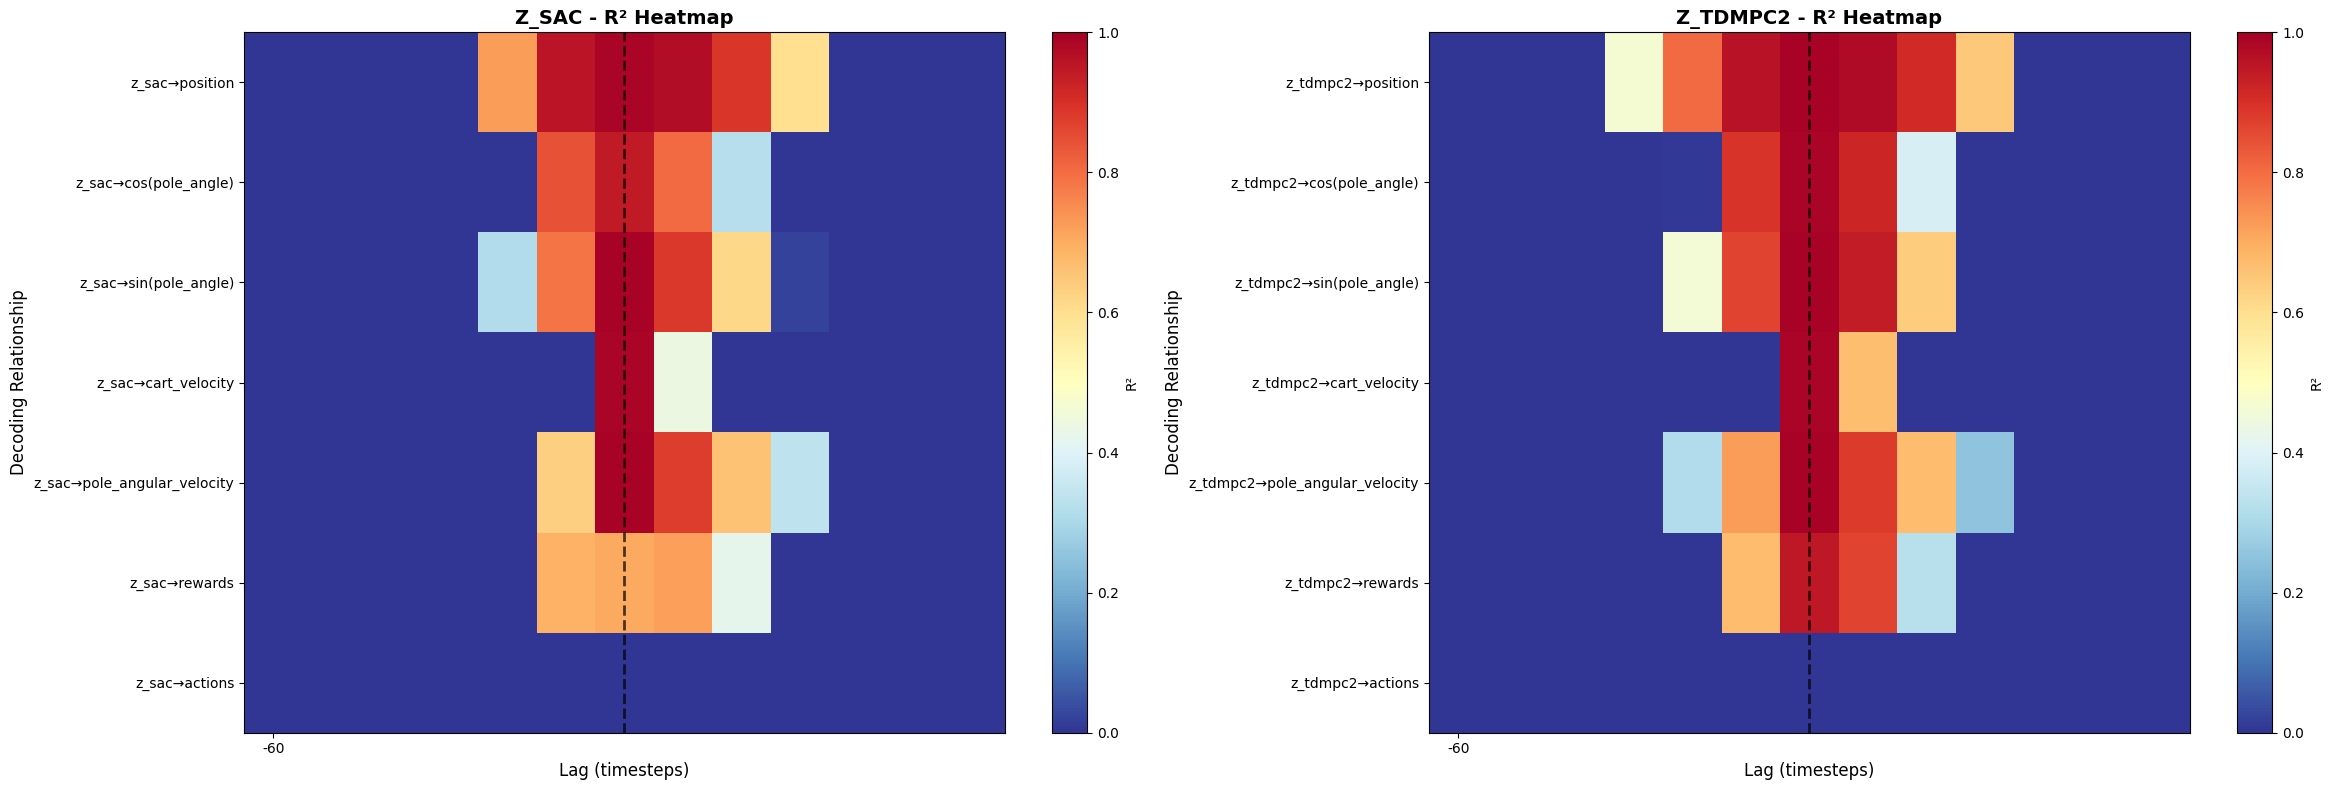

In [27]:
# Create heatmaps for R² values across lags and variables
import numpy as np

# Define the agents and regression type
agents = ['z_sac', 'z_tdmpc2']
regression_type = 'future'
model = 'linear_regression'

# Prepare data structures for heatmaps
lag_range = range(-60, 61, 10)
y_variables_for_heatmap = [
    'position', 'cos(pole_angle)', 'sin(pole_angle)', 'cart_velocity',
    'pole_angular_velocity', 'rewards', 'actions'
]

fig, axes = plt.subplots(1, len(agents), figsize=(24, 8))

for agent_idx, agent in enumerate(agents):
    # Create matrix for heatmap: rows = z_model→variable, columns = lags
    heatmap_data = []
    row_labels = []

    # For each target variable, create a row showing R² across lags
    for y_var in y_variables_for_heatmap:
        key = f'{agent}-{y_var}'

        if key in results_decoding[f'{regression_type}_{model}']:
            results = results_decoding[f'{regression_type}_{model}'][key]
            r2_mean = results['r2_mean']

            # Extract R² values for all lags
            r2_values = [r2_mean.get(lag, 0) for lag in lag_range]
            heatmap_data.append(r2_values)
            row_labels.append(f'{agent}→{y_var}')

    # Plot heatmap
    ax = axes[agent_idx]
    heatmap_data = np.array(heatmap_data)
    im = ax.imshow(heatmap_data,
                   cmap='RdYlBu_r',
                   aspect='auto',
                   interpolation='nearest',
                   vmin=0,
                   vmax=1)

    ax.set_xlabel('Lag (timesteps)', fontsize=12)
    ax.set_ylabel('Decoding Relationship', fontsize=12)
    ax.set_title(f'{agent.upper()} - R² Heatmap',
                 fontsize=14,
                 fontweight='bold')

    # Set x-axis ticks
    tick_positions = np.arange(0, len(lag_range), 20)
    tick_labels = [lag_range[i] for i in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)

    # Set y-axis ticks
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=10)

    # Add vertical line at lag=0
    zero_lag_idx = list(lag_range).index(0)
    ax.axvline(x=zero_lag_idx,
               color='black',
               linestyle='--',
               linewidth=2,
               alpha=0.7)

    plt.colorbar(im, ax=ax, label='R²')

plt.tight_layout()
plt.show()


## Analysis of the activations

In [53]:
z_sac = vars_all_stacked['z_sac']
z_tdmpc2 = vars_all_stacked['z_tdmpc2']

z_sac.shape
z_tdmpc2.shape


(7500, 512)

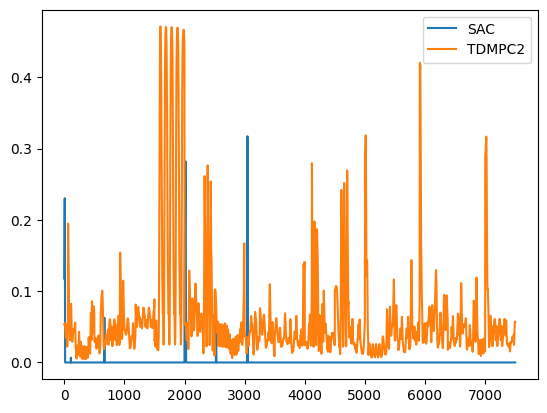

In [58]:
plt.plot(z_sac[:, 1], label='SAC')
plt.plot(z_tdmpc2[:, 1], label='TDMPC2')
plt.legend()
plt.show()


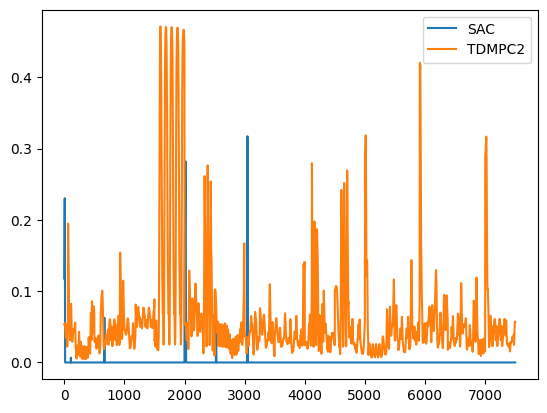

SAC: 54 components needed for 95% explained variance
TDMPC2: 35 components needed for 95% explained variance


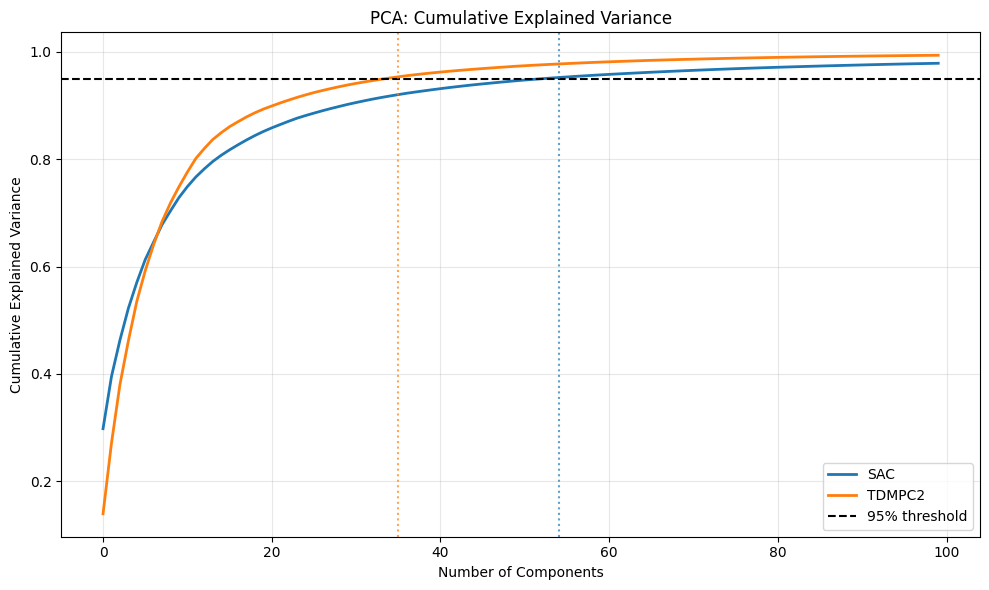

In [60]:
plt.plot(z_sac[:, 1], label='SAC')
plt.plot(z_tdmpc2[:, 1], label='TDMPC2')
plt.legend()
plt.show()

# %% cell 14a code

from sklearn.decomposition import PCA

# Perform PCA on SAC activations
components = 100
pca_sac = PCA(n_components=components)
pca_sac.fit(z_sac)
cumsum_var_sac = np.cumsum(pca_sac.explained_variance_ratio_)
n_components_sac_95 = np.argmax(cumsum_var_sac >= 0.95) + 1

# Perform PCA on TDMPC2 activations
pca_tdmpc2 = PCA(n_components=components)
pca_tdmpc2.fit(z_tdmpc2)
cumsum_var_tdmpc2 = np.cumsum(pca_tdmpc2.explained_variance_ratio_)
n_components_tdmpc2_95 = np.argmax(cumsum_var_tdmpc2 >= 0.95) + 1

print(
    f"SAC: {n_components_sac_95} components needed for 95% explained variance")
print(
    f"TDMPC2: {n_components_tdmpc2_95} components needed for 95% explained variance"
)

# Plot cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(cumsum_var_sac, label='SAC', linewidth=2)
plt.plot(cumsum_var_tdmpc2, label='TDMPC2', linewidth=2)
plt.axhline(y=0.95, color='black', linestyle='--', label='95% threshold')
plt.axvline(x=n_components_sac_95, color='C0', linestyle=':', alpha=0.7)
plt.axvline(x=n_components_tdmpc2_95, color='C1', linestyle=':', alpha=0.7)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [64]:
import numpy as np


def participation_ratio(Z, center=True, eps=1e-12):
    """
    Effective rank / participation ratio from the eigen-spectrum of the covariance.

    Args:
        Z: array of shape (N, d)  [samples x features]
        center: subtract mean over samples before computing spectrum
        eps: numerical floor

    Returns:
        r_eff: float in [1, d]
        evals: eigenvalues of covariance (sorted descending), shape (d,)
    """
    Z = np.asarray(Z, dtype=np.float64)
    if Z.ndim != 2:
        raise ValueError(f"Z must be 2D (N,d), got shape {Z.shape}")

    if center:
        Z = Z - Z.mean(axis=0, keepdims=True)

    # covariance (d x d). Use bias=True for 1/N normalization; doesn't matter for the ratio.
    C = np.cov(Z, rowvar=False, bias=True)

    # eigenvalues of symmetric covariance
    evals = np.linalg.eigvalsh(C)
    evals = np.maximum(evals, 0.0)  # guard tiny negatives from numerical error
    evals = np.sort(evals)[::-1]

    s1 = evals.sum()
    s2 = np.square(evals).sum()

    r_eff = (s1 * s1) / (s2 + eps)
    d = Z.shape[1]
    r_eff = float(np.clip(r_eff, 1.0, float(d)))
    return r_eff, evals


In [68]:
r_eff_sac, evals_sac = participation_ratio(z_sac)
print(f"Participation ratio SAC: {r_eff_sac}")

r_eff_tdmpc2, evals_tdmpc2 = participation_ratio(z_tdmpc2)
print(f"Participation ratio TDMPC2: {r_eff_tdmpc2}")


Participation ratio SAC: 8.63050993312764
Participation ratio TDMPC2: 13.679363211986852


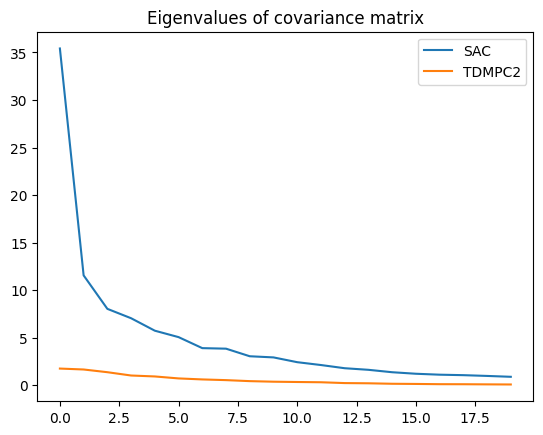

In [73]:
plt.plot(evals_sac[:20], label='SAC')
plt.plot(evals_tdmpc2[:20], label='TDMPC2')
plt.title('Eigenvalues of covariance matrix')
plt.legend()
plt.show()

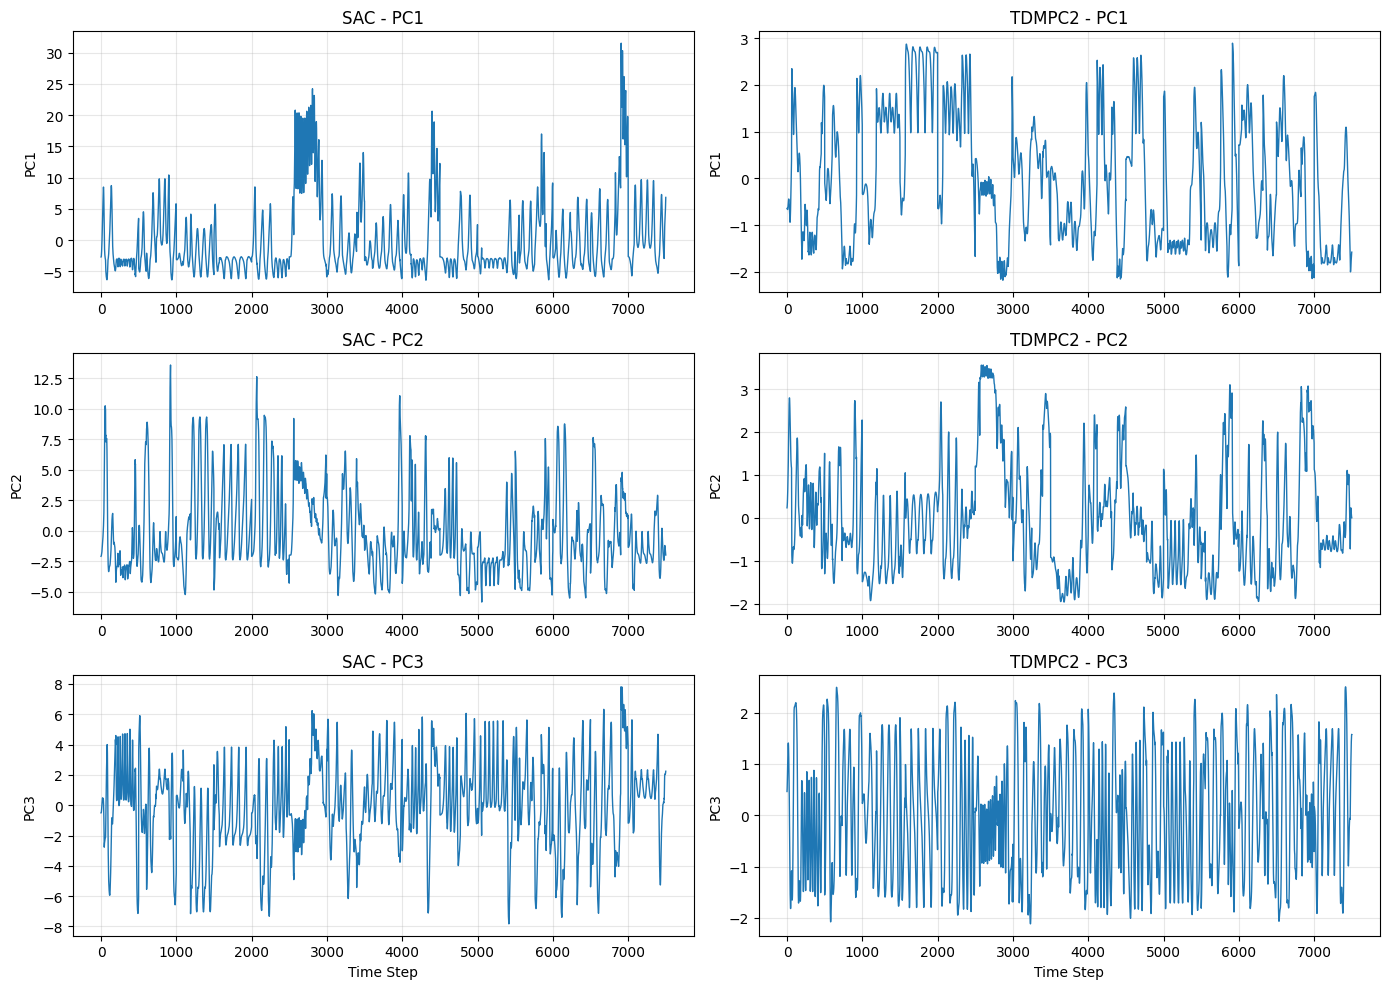

In [61]:
# Transform data to PC space
z_sac_pca = pca_sac.transform(z_sac)
z_tdmpc2_pca = pca_tdmpc2.transform(z_tdmpc2)

# Plot first 3 PCs for both SAC and TDMPC2
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i in range(3):
    # SAC
    axes[i, 0].plot(z_sac_pca[:, i], linewidth=1)
    axes[i, 0].set_title(f'SAC - PC{i+1}')
    axes[i, 0].set_ylabel(f'PC{i+1}')
    axes[i, 0].grid(True, alpha=0.3)

    # TDMPC2
    axes[i, 1].plot(z_tdmpc2_pca[:, i], linewidth=1)
    axes[i, 1].set_title(f'TDMPC2 - PC{i+1}')
    axes[i, 1].set_ylabel(f'PC{i+1}')
    axes[i, 1].grid(True, alpha=0.3)

axes[2, 0].set_xlabel('Time Step')
axes[2, 1].set_xlabel('Time Step')

plt.tight_layout()
plt.show()


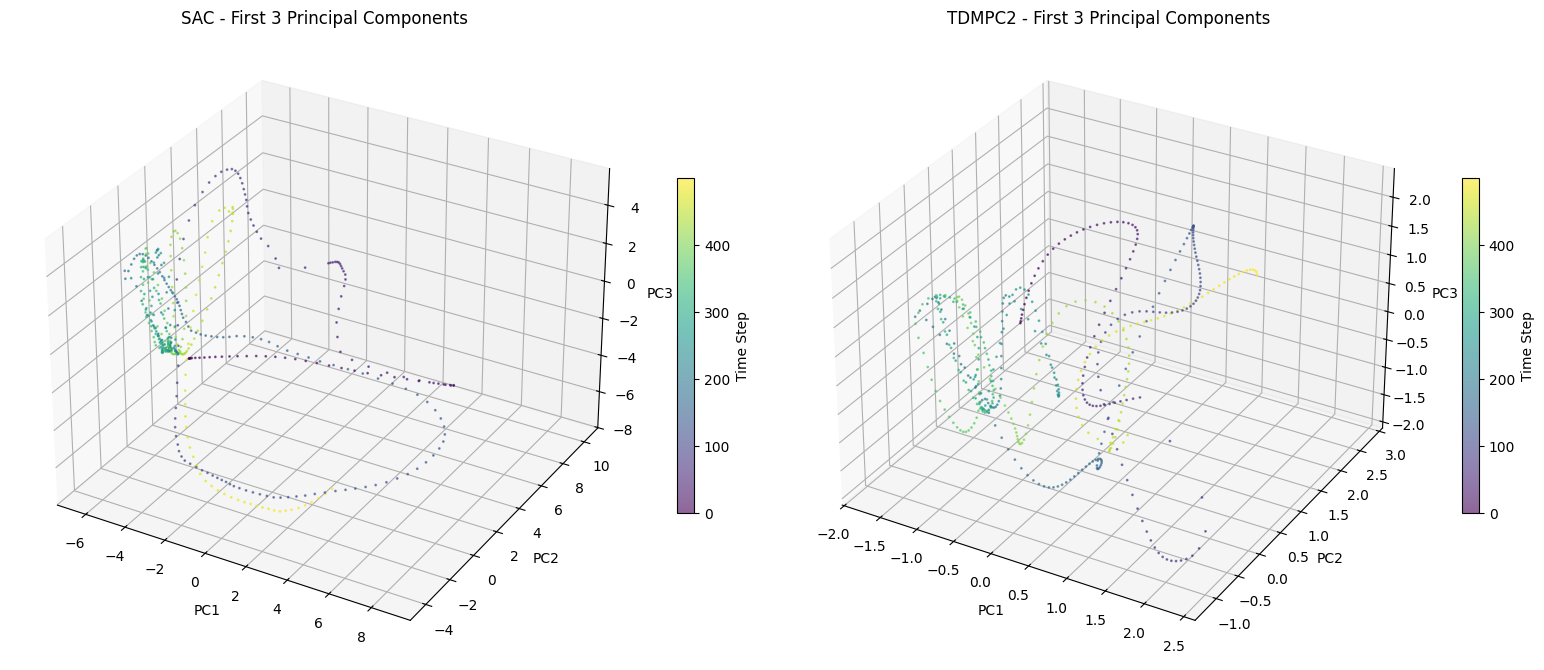

In [75]:
# Transform data to PC space
z_sac_pca = pca_sac.transform(z_sac)
z_tdmpc2_pca = pca_tdmpc2.transform(z_tdmpc2)

# Plot first 3 PCs in 3D for both SAC and TDMPC2
fig = plt.figure(figsize=(16, 7))

# Create time-based color mapping
time_sac = np.arange(len(z_sac_pca))[:500]
time_tdmpc2 = np.arange(len(z_tdmpc2_pca))[:500]

# SAC 3D plot
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(z_sac_pca[:500, 0],
                       z_sac_pca[:500, 1],
                       z_sac_pca[:500, 2],
                       c=time_sac,
                       cmap='viridis',
                       s=1,
                       alpha=0.6)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')
ax1.set_title('SAC - First 3 Principal Components')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Time Step', shrink=0.5)

# TDMPC2 3D plot
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(z_tdmpc2_pca[:500, 0],
                       z_tdmpc2_pca[:500, 1],
                       z_tdmpc2_pca[:500, 2],
                       c=time_tdmpc2,
                       cmap='viridis',
                       s=1,
                       alpha=0.6)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
ax2.set_title('TDMPC2 - First 3 Principal Components')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax2, label='Time Step', shrink=0.5)

plt.tight_layout()
plt.show()


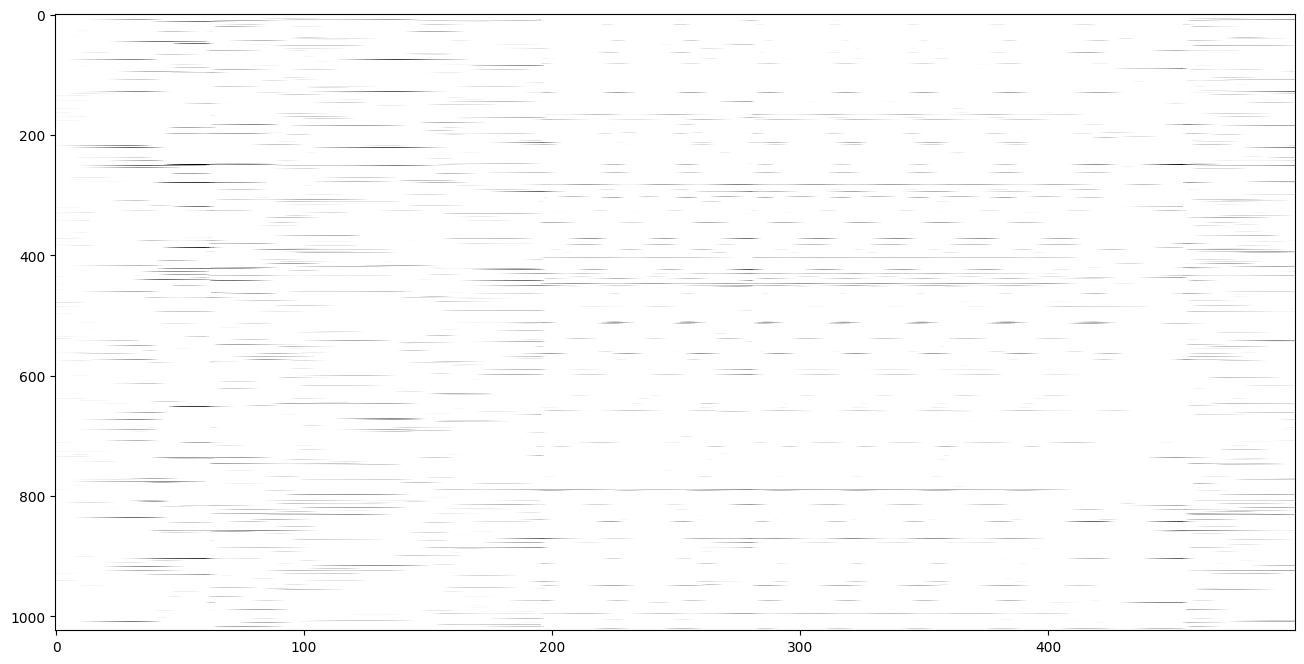

In [79]:
plt.figure(figsize=(16, 8))
plt.imshow(zs_sac[0].T, cmap='gray_r', aspect='auto', interpolation='none')

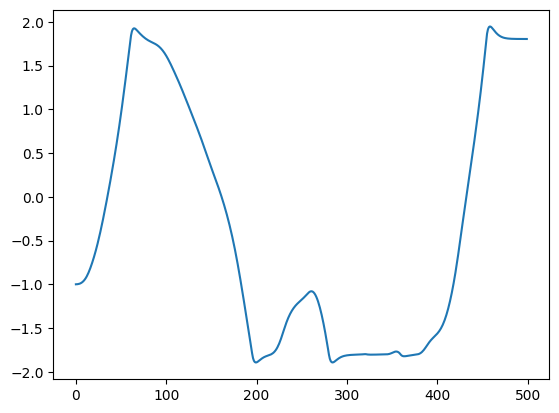

In [78]:
plt.plot(obs_episodes[0][:, 0], label='TDMPC2')

In [100]:
z_fake = torch.randn(500, 1024)

# %% cell 31 code

# Linear regression between z_fake and obs_episode
train_episode = 0
X_fake = z_fake.numpy()  # random latent representations
y_fake = obs_episodes[train_episode][:, 0]  # position from first episode

# Fit linear regression on random features
model_fake = LinearRegression()
model_fake.fit(X_fake, y_fake)

# Predict and calculate R²
y_pred_fake = model_fake.predict(X_fake)
r2_fake = r2_score(y_fake, y_pred_fake)

print(f"R² score (random features): {r2_fake:.4f}")
print(f"X_fake shape: {X_fake.shape}")
print(f"y_fake shape: {y_fake.shape}")


R² score (random features): 1.0000
X_fake shape: (500, 1024)
y_fake shape: (500,)


## Analyze input data

In [42]:
# Load passive data variables
with open(
        '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_sac_vs_tdmpc2/passive_data/vars_all.pkl',
        'rb') as f:
    vars_all = pickle.load(f)


In [46]:
vars_all_stacked = {}
for key in vars_all.keys():
    vars_all_stacked[key] = np.concatenate(vars_all[key], axis=0)

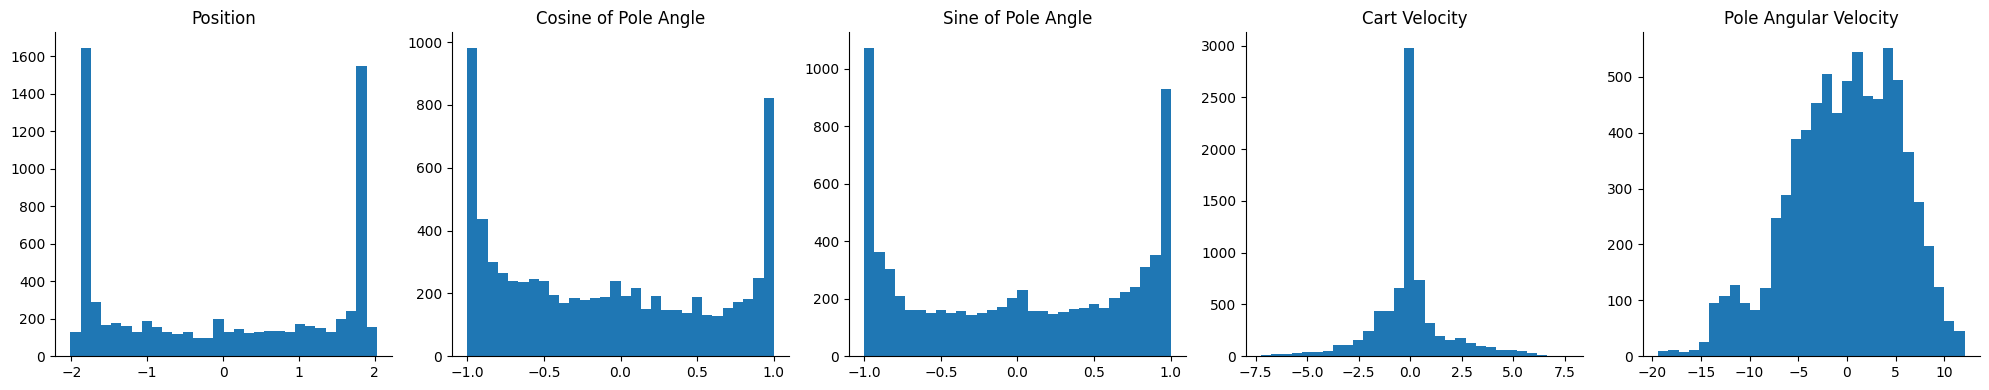

In [50]:
map_keys = {
    0: 'Position',
    1: 'Cosine of Pole Angle',
    2: 'Sine of Pole Angle',
    3: 'Cart Velocity',
    4: 'Pole Angular Velocity',
}

obs_episodes_stacked = vars_all_stacked['obs']
n_dims = obs_episodes_stacked.shape[1]
fig, axes = plt.subplots(1, n_dims, figsize=(4 * n_dims, 4))
for i in range(n_dims):
    axes[i].hist(obs_episodes_stacked[:, i], bins=30)
    axes[i].set_title(f'{map_keys[i]}')
plt.tight_layout()
sns.despine()
plt.show()

In [92]:
ranges

[0, 10, 20, 30, 40, 50, 60]

In [96]:
 list(range(0, 10, 1)) 

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


l=0: Mean temporal correlation (t to t+0): nan
l=1: Mean temporal correlation (t to t+1): nan
l=2: Mean temporal correlation (t to t+2): nan
l=3: Mean temporal correlation (t to t+3): nan
l=4: Mean temporal correlation (t to t+4): nan
l=5: Mean temporal correlation (t to t+5): nan
l=6: Mean temporal correlation (t to t+6): nan
l=7: Mean temporal correlation (t to t+7): nan
l=8: Mean temporal correlation (t to t+8): nan
l=9: Mean temporal correlation (t to t+9): nan
l=10: Mean temporal correlation (t to t+10): nan
l=15: Mean temporal correlation (t to t+15): nan
l=20: Mean temporal correlation (t to t+20): nan
l=25: Mean temporal correlation (t to t+25): nan
l=30: Mean temporal correlation (t to t+30): nan
l=35: Mean temporal correlation (t to t+35): nan
l=40: Mean temporal correlation (t to t+40): nan
l=45: Mean temporal correlation (t to t+45): nan
l=50: Mean temporal correlation (t to t+50): nan
l=55: Mean temporal correlation (t to t+55): nan
l=60: Mean temporal correlation (t to t+

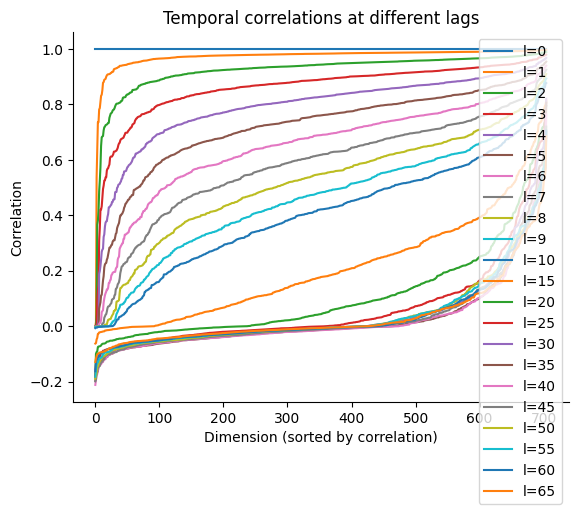

In [102]:
# Compute correlation between z_sac at time t and t+l for different lags
z_analysis = z_sac
ranges = list(range(0, 10, 1)) + list(range(10, 70, 5))
for l in ranges:
    z_t = z_analysis[:-l] if l > 0 else z_analysis  # All but last l timesteps
    z_t_plus_l = z_analysis[
        l:] if l > 0 else z_analysis  # All but first l timesteps

    # Compute correlation for each dimension
    correlations = []
    for dim in range(z_t.shape[1]):
        corr = np.corrcoef(z_t[:, dim], z_t_plus_l[:, dim])[0, 1]
        correlations.append(corr)

    # Average correlation across dimensions
    mean_correlation = np.mean(correlations)
    print(
        f"l={l}: Mean temporal correlation (t to t+{l}): {mean_correlation:.4f}"
    )

    plt.plot(sorted([c for c in correlations if not np.isnan(c)]),
             label=f'l={l}')

plt.legend()
plt.xlabel('Dimension (sorted by correlation)')
plt.ylabel('Correlation')
plt.title('Temporal correlations at different lags')
sns.despine()
plt.show()

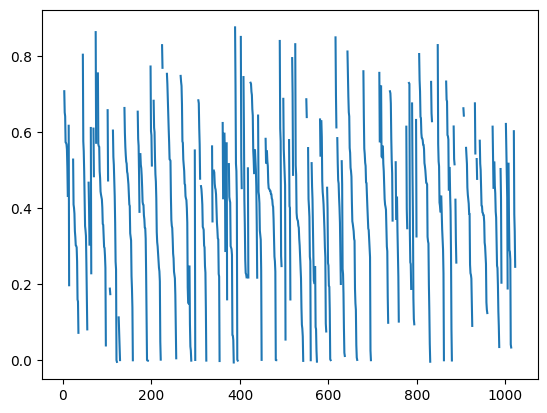

In [84]:
plt.plot(sorted(correlations, reverse=True))

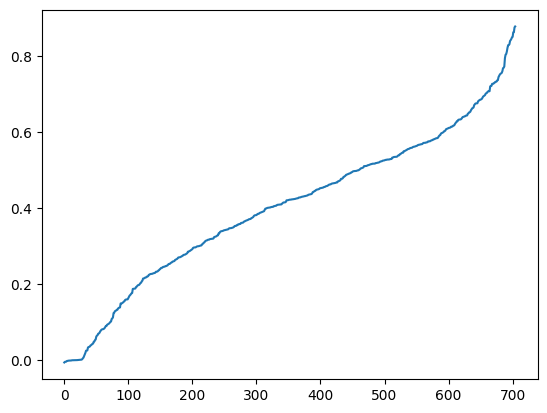

<BarContainer object of 1024 artists>

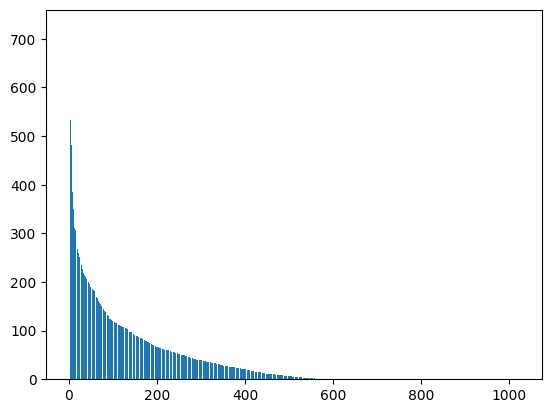

In [115]:
episode = 1
sums = z_sac[episode * 500:(episode + 1) * 500].sum(axis=0)
sorted_indices = np.argsort(np.abs(sums))[::-1]
plt.bar(range(z_sac.shape[1]), sums[sorted_indices])

In [117]:
z_sac.shape

(7500, 1024)

In [118]:
z_tdmpc2.shape

(7500, 512)

In [120]:
# Compute linear CKA between z_sac and z_tdmpc2
def linear_cka(X, Y):
    """
    Compute linear CKA between two representations X and Y.
    X: (n_samples, n_features_X)
    Y: (n_samples, n_features_Y)
    """
    # Center the matrices
    X = X - X.mean(axis=0)
    Y = Y - Y.mean(axis=0)

    # Compute HSIC (Hilbert-Schmidt Independence Criterion)
    XtX = X.T @ X
    YtY = Y.T @ Y

    hsic_xy = np.trace(XtX @ YtY)
    hsic_xx = np.trace(XtX @ XtX)
    hsic_yy = np.trace(YtY @ YtY)

    # CKA = HSIC(X,Y) / sqrt(HSIC(X,X) * HSIC(Y,Y))
    cka = hsic_xy / np.sqrt(hsic_xx * hsic_yy)

    return cka


# Compute CKA between SAC and TD-MPC2 representations
cka_score = linear_cka(z_sac[:, 512:], z_tdmpc2)
print(f"Linear CKA between z_sac and z_tdmpc2: {cka_score:.4f}")


Linear CKA between z_sac and z_tdmpc2: 0.0251


In [ ]:
import pickle

# Read the episode data
with open(
        '/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep/20260104_185854/activations/episode_data.pkl',
        'rb') as f:
    episode_data = pickle.load(f)

np.array(episode_data['data']['observations']).shape  #(Tx5)
np.concatenate(episode_data['data']['latent_states'], axis=0).shape  #(Tx512)
np.array(episode_data['data']['actions']).reshape(-1, 1).shape  #(Tx1)
np.array(episode_data['data']['rewards']).reshape(-1, 1).shape  #(Tx1)


{'metadata': {'seed': 1,
  'initial_state': [-1.0, 3.7699111843077517],
  'checkpoint': 'logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/100000.pt',
  'model_step': 100000,
  'task': 'cartpole-swingup',
  'episode_idx': 0,
  'episode_length': 500,
  'total_reward': 781.8728032285871,
  'timestamp': '2026-01-04T18:59:17.447361',
  'obs_type': 'state'},
 'data': {'observations': [array([-1.        , -0.809017  , -0.58778524,  0.        ,  0.        ],
         dtype=float32),
   array([-0.9981641 , -0.80873364, -0.5881751 ,  0.18358782,  0.04816227],
         dtype=float32),
   array([-0.99265665, -0.8078847 , -0.58934057,  0.3671557 ,  0.09592826],
         dtype=float32),
   array([-0.9834781 , -0.80647385, -0.59126973,  0.5506857 ,  0.14290711],
         dtype=float32),
   array([-0.9706325 , -0.80450934, -0.59394   ,  0.73386973,  0.18837494],
         dtype=float32),
   array([-0.954317  , -0.80213654, -0.59714067,  0.89766634,  0.20979206],
         dtype=float32),
   array

In [130]:
np.array(episode_data['data']['observations']).shape
np.concatenate(episode_data['data']['latent_states'], axis=0).shape
np.array(episode_data['data']['actions']).shape
np.array(episode_data['data']['rewards']).shape

(500,)